# Statistics for comparing attended vs. unattended speech

In [126]:
# IMPORT LIBRARIES

import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import matplotlib.pyplot as plt
import eelbrain
import numpy as np
from scipy import stats



In [140]:
# Load envelope TRFs for all subjects
attended_corr = []
unattended_corr = []
mean_attended_corr = []
mean_unattended_corr = []

SUBJECTS = helper_functions.get_subjects()

for subject in SUBJECTS:
    attended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_attended_trf.pickle'
    unattended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_unattended_trf.pickle'

    if attended_trf_path.exists() and unattended_trf_path.exists():
        trf_attended = eelbrain.load.unpickle(attended_trf_path)
        trf_unattended = eelbrain.load.unpickle(unattended_trf_path)
        print(trf_attended.h.dims)
                
        attended_corr.append(trf_attended.r)
        unattended_corr.append(trf_unattended.r)
        mean_attended_corr.append(trf_attended.r.mean("sensor"))
        mean_unattended_corr.append(trf_unattended.r.mean("sensor"))
        # Note that r does not take into account the model’s ability to predict the magnitude of the response, only its shape; for a measure that reflects both, consider using proportion_explained.

        print(f"Loaded pearson correlations for {subject}")
    else:
        print(f"TRF files for {subject} not found, skipping.")
        

print(f"Loaded correlations for {len(SUBJECTS)} subjects")

(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S1
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S2
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S3
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S4
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S5
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S6
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S7
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S8
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S9
(<Sensor n=64, name='biosemi64'>, UTS(-0.115625, 0.015625, 72))
Loaded pearson correlations for S10
(<Sensor 

In [128]:
attended_corr[0], unattended_corr[0], mean_attended_corr[0], mean_unattended_corr[0]

(<NDVar 'Correlation': 64 sensor>,
 <NDVar 'Correlation': 64 sensor>,
 np.float64(0.01201488734546728),
 np.float64(0.010073663253761437))

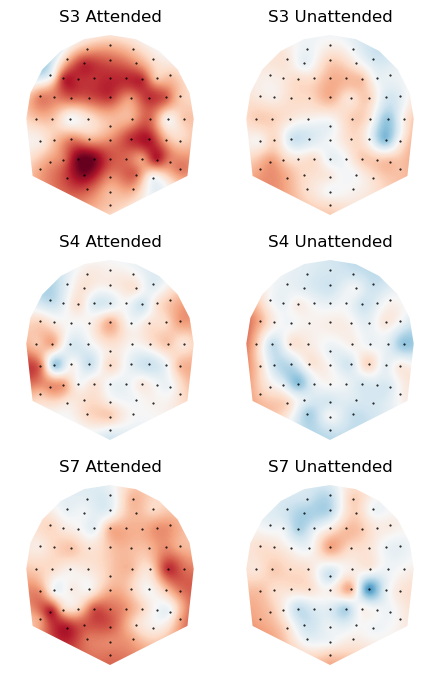

In [129]:

# Select the subjects you want
subjects_to_plot = [3,4,7]

# Build a list of NDVars to plot for each subject
# Each element is [attended_corr[subj], unattended_corr[subj]]
plots = [
    [attended_corr[s], unattended_corr[s]] 
    for s in subjects_to_plot
]

# Flatten the list so Topomap sees multiple NDVars
# Eelbrain will automatically make one subplot per NDVar
plots_flat = [item for pair in plots for item in pair]

# Titles: we have 2 conditions per subject
titles = []
for i in subjects_to_plot:
    titles.extend([f"S{i} Attended", f"S{i} Unattended"])

# Create the topomap
p = eelbrain.plot.Topomap(
    plots_flat,
    axtitle=titles,
    cmap='RdBu_r',
)

# Statistical difference between attended and unattended speech

In [130]:
att = np.array(mean_attended_corr)
unatt = np.array(mean_unattended_corr)

# Fisher transform
att_z = np.arctanh(att)
unatt_z = np.arctanh(unatt)

# Paired test
t, p = stats.ttest_rel(att_z, unatt_z)

print("t =", t)
print("p =", p)

t = 4.076323880851134
p = 0.000785962631967903
